**1.Tải thư viện**

In [1]:
%pip install scikit-learn xgboost matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


**2.Import thư viện , đọc dữ liệu**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib


df = pd.read_csv('dataset_raw.csv')
print("Kích thước tập dữ liệu:", df.shape)
df.head()

Kích thước tập dữ liệu: (300, 9)


,query_string,query_length,has_where,has_group_by,has_order_by,has_like,row_count,execution_time_ms,is_slow_query
0,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,29.573441,1
1,"SELECT status, COUNT(*) FROM customer_transact...",67,0,1,0,0,4,42.774677,1
2,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,25.771141,1
3,SELECT customer_name FROM customer_transaction...,83,1,0,0,1,2132,26.340008,1
4,SELECT * FROM customer_transactions WHERE age ...,91,1,0,1,0,23825,158.545256,1


**3.Phân tích dữ liệu**

/tmp/ipykernel_452524/597820140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_slow_query', data=df, palette='viridis')


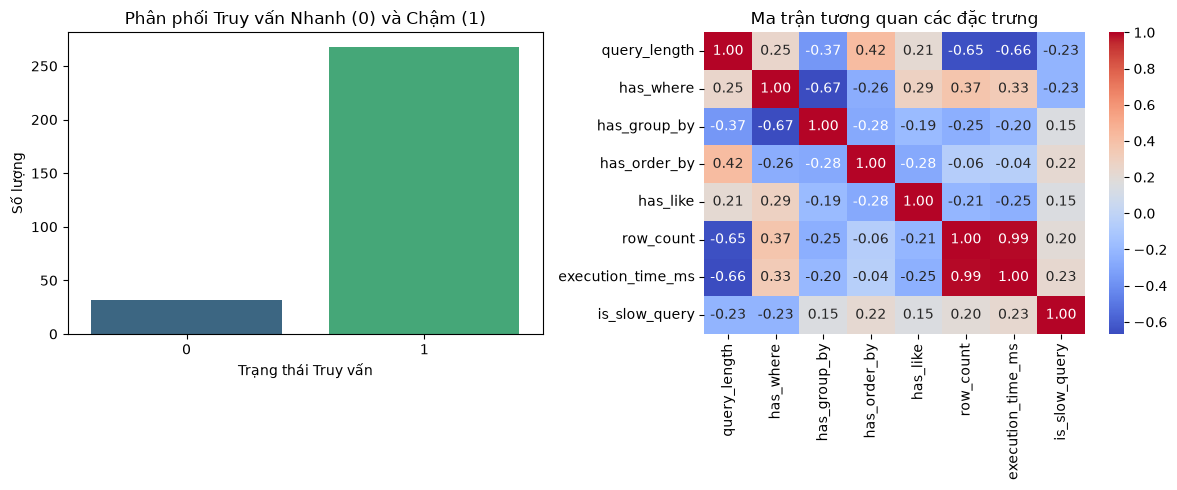

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='is_slow_query', data=df, palette='viridis')
plt.title('Phân phối Truy vấn Nhanh (0) và Chậm (1)')
plt.xlabel('Trạng thái Truy vấn')
plt.ylabel('Số lượng')

plt.subplot(1, 2, 2)
corr_matrix = df.drop(columns=['query_string']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan các đặc trưng')

plt.tight_layout()
plt.show()

**4.Tiền xử lý dữ liệu**

In [4]:
X = df[['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']]
y = df['is_slow_query']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số mẫu tập Train: {X_train.shape[0]}")
print(f"Số mẫu tập Test: {X_test.shape[0]}")

Số mẫu tập Train: 240
Số mẫu tập Test: 60


**5.Huyến luyện mô hình**

In [5]:
# 1. Kiểm tra tình trạng hiện tại của nhãn
print("Phân phối nhãn cũ:")
print(df['is_slow_query'].value_counts())

# 2. Cập nhật lại nhãn: Lấy mức thời gian ở giữa (Median) làm ngưỡng phân chia
median_time = df['execution_time_ms'].median()
print(f"\nThời gian chạy trung vị là: {median_time:.2f} ms")

# Bất cứ truy vấn nào chạy lâu hơn mức trung bình này sẽ bị coi là chậm (1)
df['is_slow_query'] = (df['execution_time_ms'] > median_time).astype(int)

print("\nPhân phối nhãn MỚI (đã cân bằng):")
print(df['is_slow_query'].value_counts())

# 3. Chia lại tập Train / Test
X = df[['query_length', 'has_where', 'has_group_by', 'has_order_by', 'has_like']]
y = df['is_slow_query']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nĐã cập nhật lại X_train, y_train thành công!")

Phân phối nhãn cũ:
is_slow_query
1    268
0     32
Name: count, dtype: int64

Thời gian chạy trung vị là: 34.41 ms

Phân phối nhãn MỚI (đã cân bằng):
is_slow_query
0    150
1    150
Name: count, dtype: int64

Đã cập nhật lại X_train, y_train thành công!


In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("Đã huấn luyện xong Random Forest và XGBoost!")

Đã huấn luyện xong Random Forest và XGBoost!


**6.Đánh giá mô hình**

Random Forest Accuracy: 0.9333
XGBoost Accuracy: 0.9333


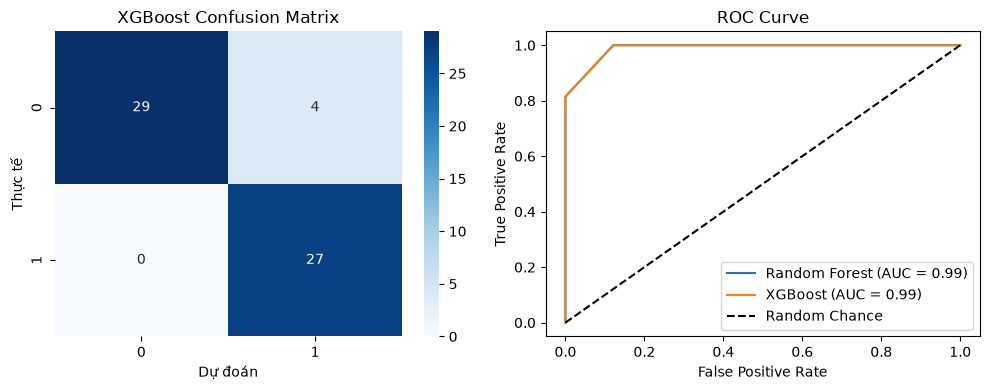


--- Chi tiết phân loại của XGBoost ---
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        33
           1       0.87      1.00      0.93        27

    accuracy                           0.93        60
   macro avg       0.94      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



In [7]:
# Đánh giá Accuracy
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

# Vẽ Confusion Matrix cho XGBoost
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# Vẽ đường cong ROC-AUC
plt.subplot(1, 2, 2)
# Lấy xác suất dự đoán (probability)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# In báo cáo chi tiết cho XGBoost
print("\n--- Chi tiết phân loại của XGBoost ---")
print(classification_report(y_test, xgb_preds))

**7.Lưu mô hình tốt nhất**

In [8]:
# Chọn XGBoost làm mô hình chính thức và lưu lại
model_filename = 'sql_predictor.pkl'
joblib.dump(xgb_model, model_filename)

print(f"Đã lưu mô hình thành công vào file: {model_filename}")

Đã lưu mô hình thành công vào file: sql_predictor.pkl


In [9]:
import json
from pathlib import Path

model_dir = Path('.')
feature_names = list(X.columns)
feature_list_path = model_dir / 'sql_feature_names.json'
model_info_path = model_dir / 'sql_model_info.json'

with feature_list_path.open('w', encoding='utf-8') as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)

model_info = {
    'model_file': model_filename,
    'feature_names_file': str(feature_list_path),
    'feature_names': feature_names,
    'scaler_file': None,
    'model_type': 'XGBoost'
}

with model_info_path.open('w', encoding='utf-8') as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

print(f'Saved feature names to {feature_list_path}')
print(f'Saved model info to {model_info_path}')
print('No scaler was used in this pipeline, so scaler_file is set to None.')

Saved feature names to sql_feature_names.json
Saved model info to sql_model_info.json
No scaler was used in this pipeline, so scaler_file is set to None.
